<a href="https://colab.research.google.com/github/agcode-maker/cir-yield-curve-modeling/blob/main/notebooks/CIR_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Data Loading and Initial Exploration

The objective of this section is to understand the structure of the dataset before performing any preprocessing or model calibration.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [4]:
train_df = pd.read_csv("train_data.csv")
test_df = pd.read_csv("test_data.csv")
test_3m_df = pd.read_csv("test_data_3M.csv")
train_df.describe()


,ZC025YR,ZC050YR,ZC075YR,ZC100YR,ZC200YR,ZC500YR,ZC1000YR,ZC2000YR,ZC3000YR
count,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000,1976.000000
mean,0.016699,0.017885,0.018529,0.019174,0.018063,0.018109,0.020226,0.022823,0.022619
std,0.016642,0.016760,0.016650,0.016587,0.013661,0.010396,0.008805,0.007136,0.006601
min,0.000486,0.000878,0.001054,0.001227,0.001417,0.002786,0.004451,0.008394,0.006921
25%,0.004621,0.005190,0.005449,0.005729,0.005897,0.009570,0.014451,0.017739,0.017895
50%,0.011912,0.013815,0.015304,0.016335,0.015471,0.015981,0.018905,0.022472,0.022258
75%,0.017112,0.019378,0.021077,0.022743,0.025553,0.026415,0.027340,0.028148,0.027408
max,0.051962,0.053195,0.054040,0.054941,0.048496,0.043147,0.042232,0.040687,0.039306


In [7]:
train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()
test_3m_df.columns = test_3m_df.columns.str.strip()

### Column Name Standardization

The raw CSV files contained leading whitespace in several column names.
These were removed using `str.strip()` to ensure consistent column referencing.

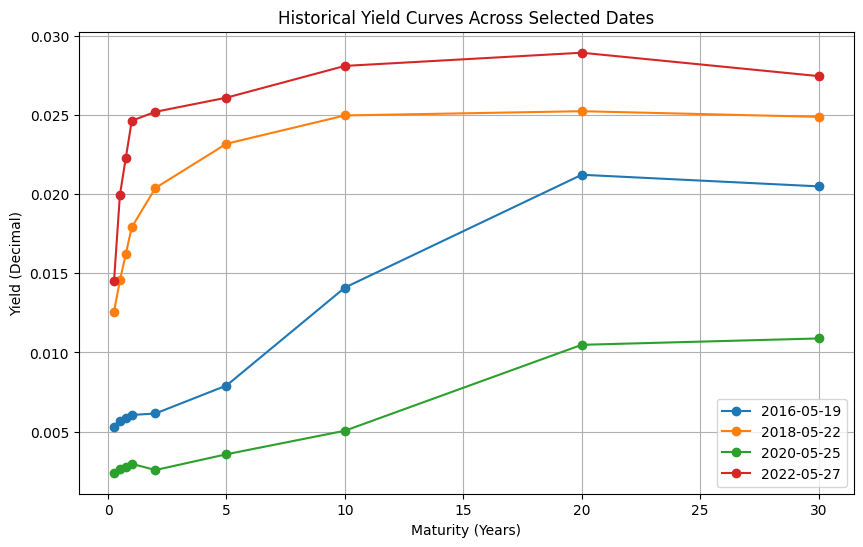

In [9]:
sample_dates = [0, 500, 1000, 1500]

maturities = [0.25, 0.5, 0.75, 1, 2, 5, 10, 20, 30]

yield_cols = [
    "ZC025YR",
    "ZC050YR",
    "ZC075YR",
    "ZC100YR",
    "ZC200YR",
    "ZC500YR",
    "ZC1000YR",
    "ZC2000YR",
    "ZC3000YR"
]

plt.figure(figsize=(10,6))

for idx in sample_dates:
    plt.plot(
        maturities,
        train_df.loc[idx, yield_cols],
        marker='o',
        label=str(train_df.loc[idx, "Date"])
    )

plt.xlabel("Maturity (Years)")
plt.ylabel("Yield (Decimal)")
plt.title("Historical Yield Curves Across Selected Dates")
plt.legend()
plt.grid(True)

plt.show()

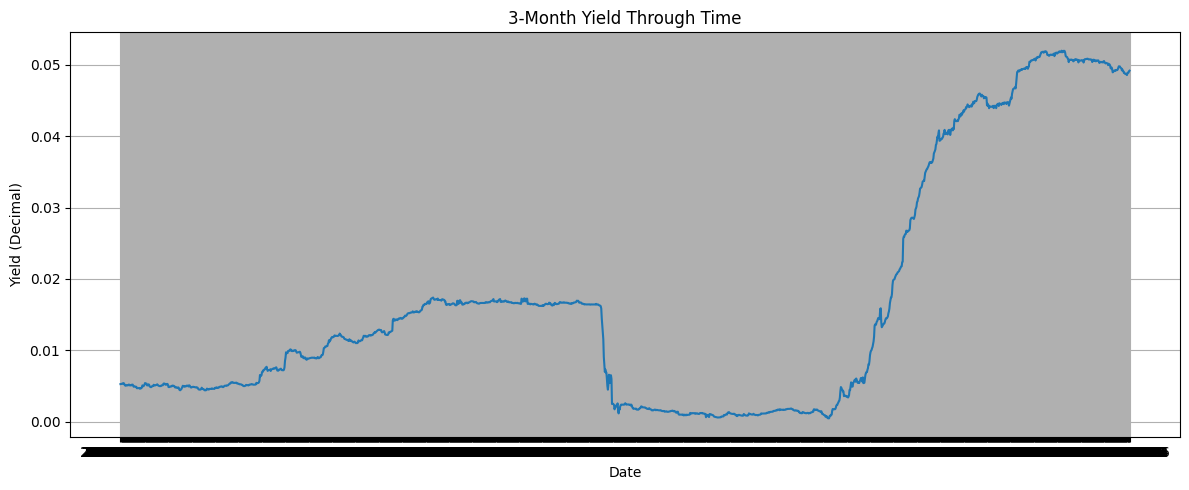

In [11]:
plt.figure(figsize=(12,5))

plt.plot(train_df["Date"], train_df["ZC025YR"])

plt.title("3-Month Yield Through Time")
plt.xlabel("Date")
plt.ylabel("Yield (Decimal)")

plt.grid(True)

plt.tight_layout()

plt.show()

## Why Maximum Likelihood Estimation?

The CIR model describes the evolution of the short rate as a stochastic process. To estimate the model parameters, we use Maximum Likelihood Estimation (MLE), which selects the parameter values that maximize the probability of observing the historical interest-rate data. Unlike visual fitting or ad hoc methods, MLE provides a statistically rigorous and reproducible calibration framework.

In [12]:
r = train_df["ZC025YR"].copy()

r.head()

,ZC025YR
0,0.005283
1,0.005286
2,0.005298
3,0.005351
4,0.005354


In [14]:
print("Observations:", len(r))
print("Minimum rate:", r.min())
print("Maximum rate:", r.max())
print("Mean rate:", r.mean())
r.describe()

Observations: 1976
Minimum rate: 0.0004864
Maximum rate: 0.0519623
Mean rate: 0.016698838967611332


,ZC025YR
count,1976.000000
mean,0.016699
std,0.016642
min,0.000486
25%,0.004621
50%,0.011912
75%,0.017112
max,0.051962


### Time Discretization

The CIR model is formulated in continuous time. Since the dataset contains daily observations, the time increment between observations is approximated as:

dt = 1 / 252

assuming 252 trading days per year.

In [15]:
r_t = r[:-1].values
r_next = r[1:].values

delta_r = r_next - r_t

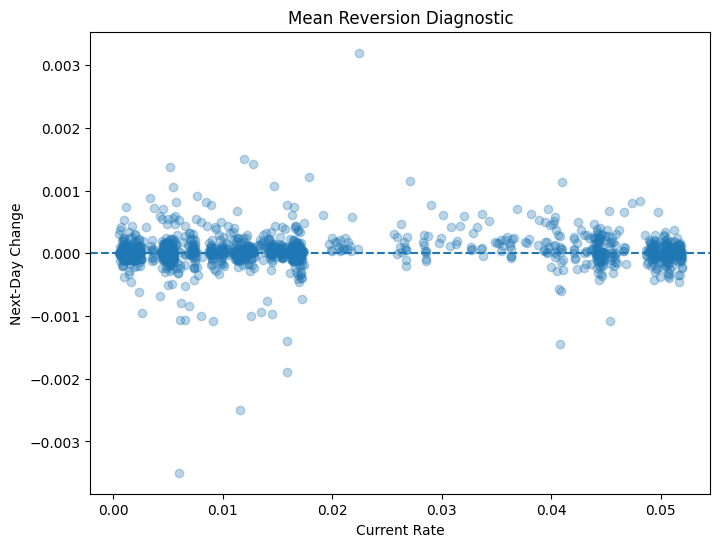

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(r_t, delta_r, alpha=0.3)

plt.xlabel("Current Rate")
plt.ylabel("Next-Day Change")
plt.title("Mean Reversion Diagnostic")

plt.axhline(0, linestyle="--")

plt.show()

..

The scatter plot of next-day rate changes against current rates does not reveal a strong visual mean-reversion pattern. Most observations cluster around zero daily change, indicating that short-term fluctuations are dominated by stochastic noise. This is consistent with the CIR framework, where the deterministic mean-reversion component is scaled by a very small daily time increment (dt ≈ 1/252). Consequently, visual inspection alone is insufficient to assess mean reversion, motivating the use of statistical calibration techniques such as OLS and Maximum Likelihood Estimation.


In [17]:
import pandas as pd

diagnostic_df = pd.DataFrame({
    "r_t": r_t,
    "delta_r": delta_r
})

diagnostic_df["bucket"] = pd.qcut(
    diagnostic_df["r_t"],
    q=10
)

bucket_means = diagnostic_df.groupby("bucket")["delta_r"].mean()

bucket_means

/tmp/ipykernel_2408/2975846697.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket_means = diagnostic_df.groupby("bucket")["delta_r"].mean()


,delta_r
bucket,
"(-0.000514, 0.00124]",0.000010
"(0.00124, 0.002]",-0.000003
"(0.002, 0.005]",0.000017
"(0.005, 0.00699]",-0.000014
"(0.00699, 0.0119]",0.000025
"(0.0119, 0.0164]",0.000027
"(0.0164, 0.0167]",0.000013
"(0.0167, 0.0354]",0.000077
"(0.0354, 0.0492]",0.000071


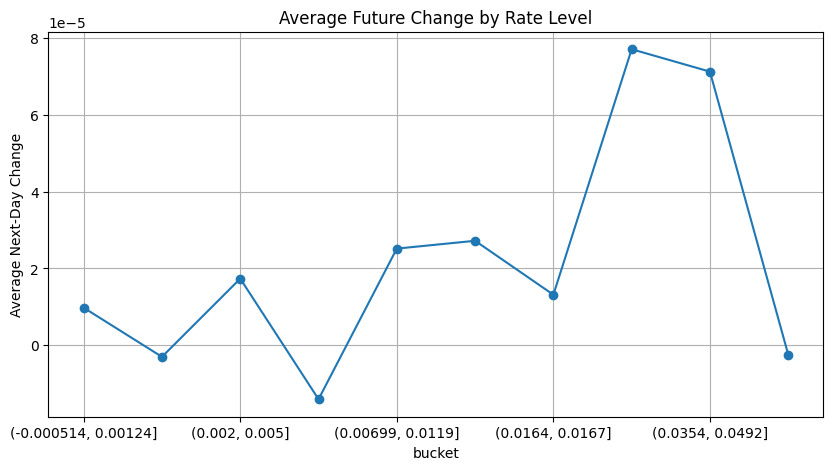

In [18]:
bucket_means.plot(
    marker="o",
    figsize=(10,5)
)

plt.title("Average Future Change by Rate Level")
plt.ylabel("Average Next-Day Change")
plt.grid(True)

plt.show()

Bucketing the data reduces observation-level noise, but no strong monotonic relationship between the current rate level and the average next-day change is observed. This suggests that the mean-reversion signal is weak relative to daily stochastic fluctuations. Consequently, visual diagnostics alone are insufficient for parameter estimation, motivating the use of formal calibration methods such as MLE.

---------------------------

## Preliminary CIR Parameter Estimation via Euler Discretization

Before performing Maximum Likelihood Estimation, we estimate the CIR parameters using an Euler discretization of the stochastic differential equation. This provides intuition regarding the mean-reversion dynamics and generates reasonable starting values for numerical optimization.

In [19]:
dt = 1/252

reg_df = pd.DataFrame({
    "r_t": r[:-1].values,
    "r_next": r[1:].values
})

reg_df["delta_r"] = reg_df["r_next"] - reg_df["r_t"]

reg_df.head()

,r_t,r_next,delta_r
0,0.005283,0.005286,0.000003
1,0.005286,0.005298,0.000012
2,0.005298,0.005351,0.000053
3,0.005351,0.005354,0.000004
4,0.005354,0.005308,-0.000047


In [20]:
import statsmodels.api as sm

In [22]:
X = sm.add_constant(reg_df["r_t"])

y = reg_df["delta_r"]

model = sm.OLS(y, X)
results = model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                delta_r   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     5.568
Date:                Wed, 03 Jun 2026   Prob (F-statistic):             0.0184
Time:                        13:32:05   Log-Likelihood:                 13710.
No. Observations:                1975   AIC:                        -2.742e+04
Df Residuals:                    1973   BIC:                        -2.740e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.753e-06   7.46e-06      1.308      0.1

Preliminary estimation via Euler discretization yielded an economically implausible positive slope coefficient, indicating that a simple linear approximation is insufficient for the full sample. This motivates the use of the exact CIR transition density and Maximum Likelihood Estimation

-----------------------------------

## Euler-Based Maximum Likelihood Estimation

Under the Euler discretization, the CIR process implies a conditional Normal distribution for the next-period rate. The model parameters are estimated by maximizing the likelihood of the observed sequence of daily interest rates.


In [51]:
# from scipy.stats import norm
# import numpy as np

# def negative_log_likelihood(params, r, dt):

#     kappa, theta, sigma = params

#     # enforce positivity
#     if kappa <= 0 or theta <= 0 or sigma <= 0:
#         return np.inf

#     r_t = r[:-1]
#     r_next = r[1:]

#     mu = r_t + kappa * (theta - r_t) * dt

#     sigma_t = sigma * np.sqrt(r_t * dt)

#     log_likelihood = norm.logpdf(
#         r_next,
#         loc=mu,
#         scale=sigma_t
#     )

#     return -np.sum(log_likelihood)

In [36]:
from scipy.optimize import minimize

In [52]:
# initial_guess = [1.0, 0.02, 0.2]

# result = minimize(
#     negative_log_likelihood,
#     x0=initial_guess,
#     args=(r_values, 1/252),
#     method="L-BFGS-B",
#     bounds=[
#         (1e-6, None),  # kappa
#         (1e-6, None),  # theta
#         (1e-6, None)   # sigma
#     ]
# )

# result.x

In [53]:
# kappa_hat, theta_hat, sigma_hat = result.x

# print("kappa =", kappa_hat)
# print("theta =", theta_hat)
# print("sigma =", sigma_hat)

# print("kappa * theta =", kappa_hat * theta_hat)

Euler-discretized MLE was explored as an introductory calibration approach. However, parameter estimates exhibited weak identification due to the dominance of daily stochastic fluctuations over the mean-reversion component.

--------------------------------------------

In [54]:
from scipy.stats import ncx2
import numpy as np

In [59]:
def cir_exact_nll(params, r, dt):

    kappa, theta, sigma = params

    if kappa <= 0 or theta <= 0 or sigma <= 0:
        return np.inf

    r_t = r[:-1]
    r_next = r[1:]

    c = (
        sigma**2
        * (1 - np.exp(-kappa * dt))
        / (4 * kappa)
    )

    d = (
        4 * kappa * theta
        / sigma**2
    )

    lam = (
        4
        * kappa
        * np.exp(-kappa * dt)
        * r_t
        /
        (
            sigma**2
            * (1 - np.exp(-kappa * dt))
        )
    )

    log_density = (
        ncx2.logpdf(
            r_next / c,
            df=d,
            nc=lam
        )
        - np.log(c)
    )
    if np.any(~np.isfinite(log_density)):
      return np.inf

    return -np.sum(log_density)

In [56]:
exact_result = minimize(
    cir_exact_nll,
    x0=[1.0, 0.02, 0.2],
    args=(r_values, 1/252),
    method="L-BFGS-B",
    bounds=[
        (1e-6, None),  # kappa
        (1e-6, None),  # theta
        (1e-6, None)   # sigma
    ]
)
exact_result.x

array([0.99961581, 0.00401956, 0.04542106])

In [58]:
exact_result.fun

np.float64(-13511.196768059248)

In [60]:
kappa, theta, sigma = exact_result.x

print("2*kappa*theta =", 2*kappa*theta)
print("sigma^2 =", sigma**2)

2*kappa*theta = 0.008036027027395953
sigma^2 = 0.002063072749295199


### Feller Condition Check

For the calibrated parameters:

- κ = 0.9996
- θ = 0.0040
- σ = 0.0454

we obtain:

2κθ = 0.008036

σ² = 0.002063

Since:

2κθ > σ²

the Feller condition is satisfied. Therefore, the calibrated CIR process remains strictly positive and is consistent with the theoretical assumptions of the model.

--------------------------------------